In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for our plots
sns.set_theme(style="whitegrid")

In [2]:
# Load the 50,000-row sample
file_path = '../amazon_reviews_sample.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 50000 rows and 15 columns.


In [3]:
# Display the first 3 rows
display(df.head(3))

# Show data types and non-null counts
print("\n--- Dataset Information ---")
df.info()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,53096384,R63J84G1LOX6R,1563890119,763187671,The Sandman Vol. 1: Preludes and Nocturnes,Books,4,0,1,N,N,ignore the review below,this is the first 8 issues of the series. it i...,1995-08-13
1,US,53096399,R1BALOA11Z06MT,1559947608,381720534,The 22 Immutable Laws of Marketing,Books,4,0,0,N,N,awesome,I've always been partial to immutable laws. Th...,1995-08-17
2,US,53096332,R1LLAY5W5PZUS4,0671701800,860650224,Contact,Books,5,1,2,N,N,Read the book. It's good.,This is a book about first contact with aliens...,1995-08-30



--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   marketplace        50000 non-null  str  
 1   customer_id        50000 non-null  int64
 2   review_id          50000 non-null  str  
 3   product_id         50000 non-null  str  
 4   product_parent     50000 non-null  int64
 5   product_title      50000 non-null  str  
 6   product_category   50000 non-null  str  
 7   star_rating        50000 non-null  int64
 8   helpful_votes      50000 non-null  int64
 9   total_votes        50000 non-null  int64
 10  vine               50000 non-null  str  
 11  verified_purchase  50000 non-null  str  
 12  review_headline    50000 non-null  str  
 13  review_body        50000 non-null  str  
 14  review_date        50000 non-null  str  
dtypes: int64(5), str(10)
memory usage: 5.7 MB


In [4]:
# Calculate and display missing values
missing_values = df.isnull().sum()
missing_only = missing_values[missing_values > 0]

if missing_only.empty:
    print("Great! No missing values found in the dataset.")
else:
    print("Missing values found in the following columns:\n")
    print(missing_only)

Great! No missing values found in the dataset.


/tmp/ipykernel_1532/1903812759.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='star_rating', palette='viridis')


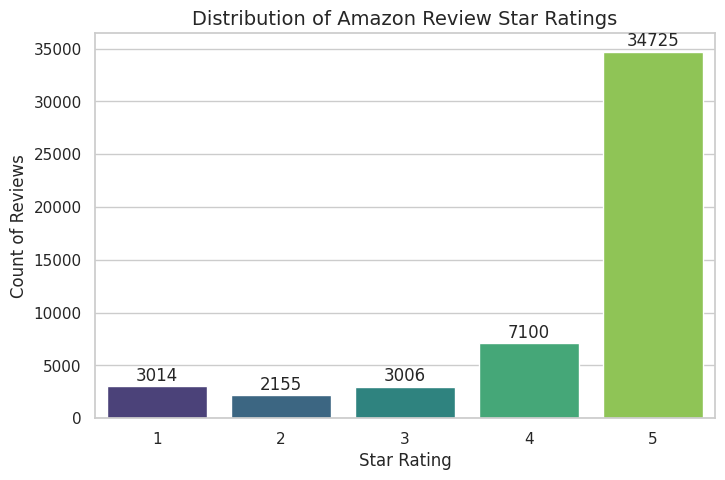

In [5]:
# Plot the distribution of the ratings
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='star_rating', palette='viridis')

plt.title('Distribution of Amazon Review Star Ratings', fontsize=14)
plt.xlabel('Star Rating', fontsize=12)
plt.ylabel('Count of Reviews', fontsize=12)

# Add counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.4, p.get_height() + 500), ha='center')

plt.show()

--- Balanced Sentiment Counts ---
sentiment
Negative    5169
Positive    5169
Name: count, dtype: int64

Total rows in balanced dataset: 10338


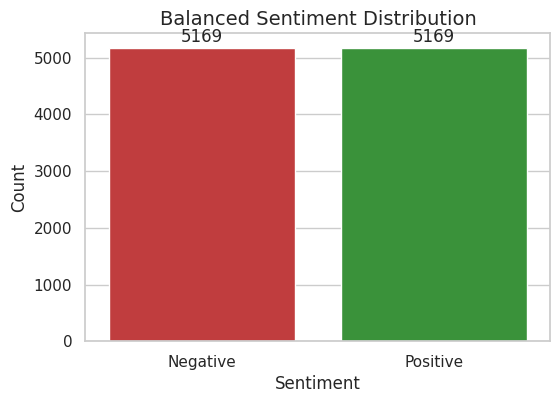

In [6]:
# 1. Drop 3-star (neutral) reviews
df_binary = df[df['star_rating'] != 3].copy()

# 2. Map ratings to Positive (4, 5) and Negative (1, 2)
df_binary['sentiment'] = df_binary['star_rating'].apply(lambda x: 'Positive' if x >= 4 else 'Negative')

# 3. Separate the positive and negative dataframes
df_pos = df_binary[df_binary['sentiment'] == 'Positive']
df_neg = df_binary[df_binary['sentiment'] == 'Negative']

# 4. Undersample the positive reviews to match the number of negative reviews
# We use random_state=42 so you get the exact same random selection every time
neg_count = len(df_neg)
df_pos_undersampled = df_pos.sample(neg_count, random_state=42)

# 5. Combine and shuffle the new balanced dataset
df_balanced = pd.concat([df_pos_undersampled, df_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

# 6. Print the new counts and visualize
print("--- Balanced Sentiment Counts ---")
print(df_balanced['sentiment'].value_counts())
print(f"\nTotal rows in balanced dataset: {len(df_balanced)}")

# Plot the new distribution
plt.figure(figsize=(6, 4))
# Note: passing hue instead of palette directly to avoid the FutureWarning!
ax = sns.countplot(data=df_balanced, x='sentiment', hue='sentiment', palette=['#d62728', '#2ca02c'], legend=False) 

plt.title('Balanced Sentiment Distribution', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.4, p.get_height() + 100), ha='center')

plt.show()

In [7]:
# Save the balanced dataset to a new CSV file
output_path = '../amazon_reviews_balanced.csv'
df_balanced.to_csv(output_path, index=False)

print(f"Success! Balanced dataset saved to {output_path}")

Success! Balanced dataset saved to ../amazon_reviews_balanced.csv
